# EWC Permutated

## Elastic Weight Consolidation (EWC)

**Key Idea**: Protect parameters that are statistically important to previous tasks according to the Fisher Information Matrix.

**Methodology**: After each task, compute the Fisher Information Matrix $F$ to estimate the 'importance' of every parameter. In subsequent tasks, the L2 penalty is scaled by $F$, strictly limiting movement on critical parameters while leaving unimportant parameters free to learn.

### Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from src import (
    set_seed, PermutedMNIST, SimpleNN, 
    train_task_with_ewc, compute_fisher_matrix, evaluate_all_tasks,
    calculate_forgetting_metrics, plot_all_results
)

set_seed(42)

num_tasks = 5
input_size = 28 * 28
hidden_size = 256
output_size = 10
learning_rate = 0.01
epochs_per_task = 5
batch_size = 64
ewc_lambda = 40.0  # EWC regularization strength

permutations = [torch.randperm(input_size) for _ in range(num_tasks)]

train_tasks = [PermutedMNIST(root="./data", train=True, permutations=permutations[i]) for i in range(num_tasks)]
test_tasks = [PermutedMNIST(root="./data", train=False, permutations=permutations[i]) for i in range(num_tasks)]

train_loaders = [DataLoader(train_tasks[i], batch_size=batch_size, shuffle=True) for i in range(num_tasks)]
test_loaders = [DataLoader(test_tasks[i], batch_size=batch_size, shuffle=False) for i in range(num_tasks)]

### Sequential Training Loop with Elastic Weight Consolidation (EWC)

In [2]:
model = SimpleNN(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

training_losses = []
task_accuracies_history = []
initial_accuracies = []

fisher_matrices = []
optimal_params = []

for task_idx in range(num_tasks):
    print(f"\n{'='*50}\nTraining on Task {task_idx+1}\n{'='*50}")
    
    task_loss, _ = train_task_with_ewc(
        model, task_idx, train_loaders[task_idx], criterion, optimizer,
        fisher_matrices if task_idx > 0 else None,
        optimal_params if task_idx > 0 else None,
        ewc_lambda=ewc_lambda, epochs=epochs_per_task
    )
    training_losses.extend(task_loss)
    
    # Compute Fisher Information Matrix for current task
    fisher = compute_fisher_matrix(model, train_loaders[task_idx], criterion)
    fisher_matrices.append(fisher)
    
    # Store optimal parameters
    optimal_param_dict = {name: param.data.clone() for name, param in model.named_parameters()}
    optimal_params.append(optimal_param_dict)
    
    print("\nEvaluating on all tasks seen so far:")
    task_accs = evaluate_all_tasks(model, test_loaders[:task_idx+1])
    
    task_accuracies_history.append(task_accs)
    initial_accuracies.append(task_accs[0] if task_idx == 0 else task_accs[-1])


Training on Task 1
Task 1, Epoch 1/5, Loss: 1.1872, Accuracy: 76.11%
Task 1, Epoch 2/5, Loss: 0.4864, Accuracy: 87.64%
Task 1, Epoch 3/5, Loss: 0.3910, Accuracy: 89.32%
Task 1, Epoch 4/5, Loss: 0.3512, Accuracy: 90.11%
Task 1, Epoch 5/5, Loss: 0.3269, Accuracy: 90.73%

Evaluating on all tasks seen so far:
Task 1 Accuracy: 91.57%

Training on Task 2
Task 2, Epoch 1/5, Loss: 0.6795, Accuracy: 82.33%
Task 2, Epoch 2/5, Loss: 0.3853, Accuracy: 89.48%
Task 2, Epoch 3/5, Loss: 0.3369, Accuracy: 90.61%
Task 2, Epoch 4/5, Loss: 0.3099, Accuracy: 91.31%
Task 2, Epoch 5/5, Loss: 0.2905, Accuracy: 91.78%

Evaluating on all tasks seen so far:
Task 1 Accuracy: 88.68%
Task 2 Accuracy: 92.61%

Training on Task 3
Task 3, Epoch 1/5, Loss: 0.6138, Accuracy: 82.30%
Task 3, Epoch 2/5, Loss: 0.3623, Accuracy: 89.75%
Task 3, Epoch 3/5, Loss: 0.3193, Accuracy: 90.88%
Task 3, Epoch 4/5, Loss: 0.2937, Accuracy: 91.64%
Task 3, Epoch 5/5, Loss: 0.2747, Accuracy: 92.24%

Evaluating on all tasks seen so far:
Task

### Metrics & Visualization

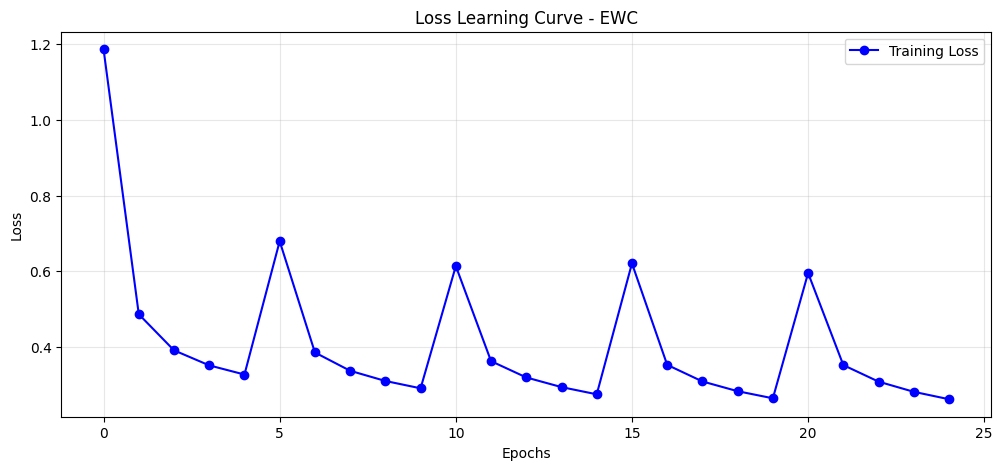

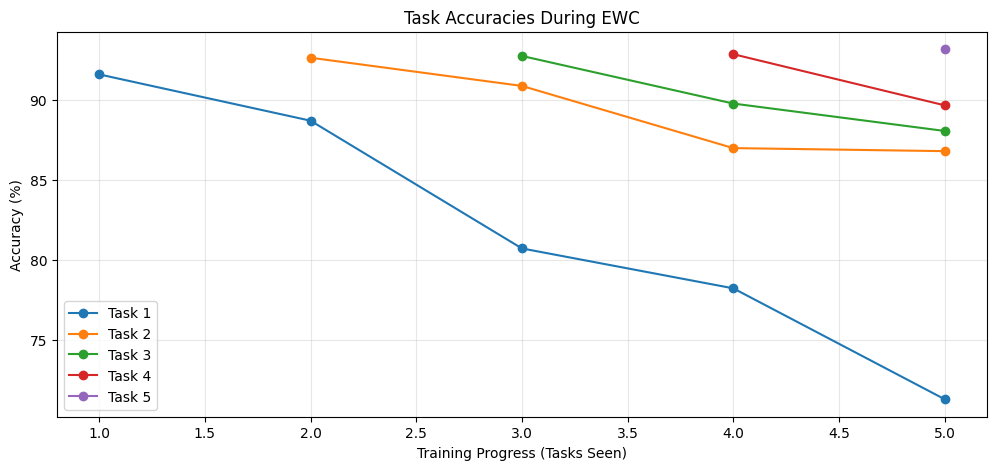


Task Accuracies Table:

              Task 1  Task 2  Task 3  Task 4  Task 5
After Task 1   91.57     NaN     NaN     NaN     NaN
After Task 2   88.68   92.61     NaN     NaN     NaN
After Task 3   80.71   90.85   92.72     NaN     NaN
After Task 4   78.22   86.97   89.75   92.83     NaN
After Task 5   71.30   86.78   88.04   89.64   93.14


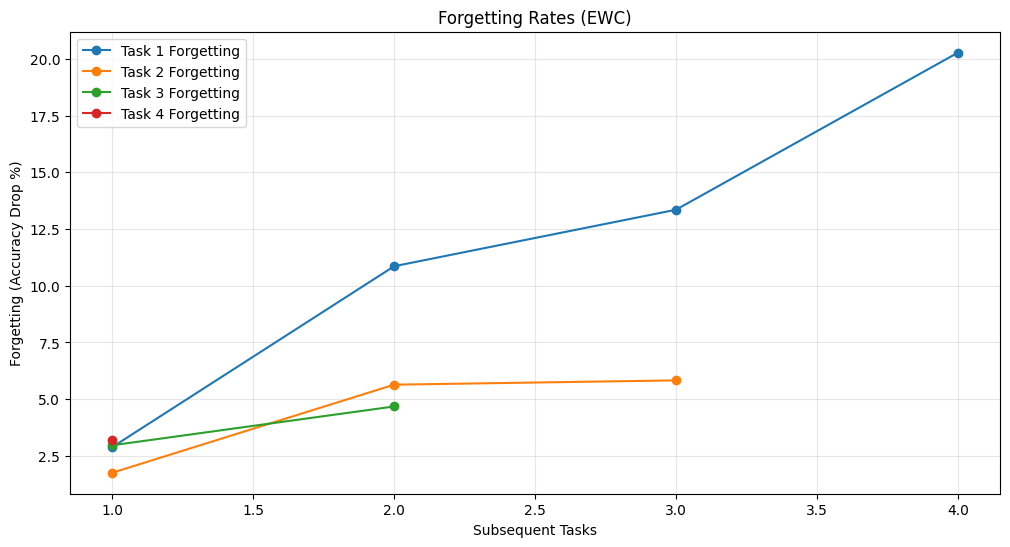

In [3]:
forgetting_rate = calculate_forgetting_metrics(task_accuracies_history, initial_accuracies)
plot_all_results(training_losses, task_accuracies_history, forgetting_rate, num_tasks, method_name='EWC')